**生成式AI的使用**: 就本次作业而言，生成式AI的使用同样受关于协作的政策约束。 与其他合作者一样，每个学生必须独立于交互的输出写下解答，并且提交中应包含说明协作性质的附注。 使用生成式AI工具实质性地完成作业的大部分内容不符合本次作业的精神，将构成对[荣誉守则]的违背(https://communitystandards.stanford.edu/policies-and-guidance/honor-code).

In [17]:
# 将您的 Google Drive 挂载到 Colab 虚拟机。
#from google.colab import drive
#drive.mount('/content/drive')

# TODO：输入您在 Drive 中保存解压后的
# 作业文件夹的名称，例如 'cs231n/assignments/assignment2/'
#FOLDERNAME = "cs231n/assignments/assignment2/"
#assert FOLDERNAME is not None, "[!] 请输入文件夹名称。"

# 现在我们已经挂载了您的 Drive，这可确保
# Colab 虚拟机的 Python 解释器能够加载
# 其中的 python 文件。
#import sys
#sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# 如果 COCO 数据集尚不存在，
# 这会将其下载到您的 Drive。
#%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
#!bash get_coco_dataset.sh
#%cd /content/drive/My\ Drive/$FOLDERNAME

# 使用 RNN 进行图像字幕生成 (Image Captioning)
在本练习中，您将实现普通的循环神经网络 (vanilla Recurrent Neural Networks) 并使用它们来训练一个能够为图像生成新字幕的模型。

In [18]:

# 设置单元格。
import time, os, json
import numpy as np
import torch
import matplotlib.pyplot as plt

from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.rnn_layers_pytorch import *
from cs231n.captioning_solver_pytorch import CaptioningSolverPytorch
from cs231n.classifiers.rnn_pytorch import CaptioningRNN
from cs231n.coco_utils import load_coco_data, sample_coco_minibatch, decode_captions
from cs231n.image_utils import image_from_url

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # Set default size of plots.
plt.rcParams["font.family"] = "SimHei"  # 强制使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号 '-' 显示为方块的问题
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

import sys
import types
import importlib

if "imp" not in sys.modules:
    imp = types.ModuleType("imp")
    imp.reload = importlib.reload
    sys.modules["imp"] = imp

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# COCO 数据集
对于本练习，我们将使用 2014 年发布的 [COCO dataset](https://cocodataset.org/), 这是图像字幕生成的标准测试平台。 该数据集由 80,000 张训练图像和 40,000 张验证图像组成， 每张图像都标注了 5 个由 Amazon Mechanical Turk 工作人员编写的字幕。

**图像特征 (Image features)**。我们已经为您对数据进行了预处理并提取了特征。 对于所有图像，我们已经从在 ImageNet 上预训练的 VGG-16 网络的 fc7 层中提取了特征， 这些特征存储在 `train2014_vgg16_fc7.h5` 和 `val2014_vgg16_fc7.h5` 文件中。 为了减少处理时间和内存需求， 我们使用主成分分析 (PCA) 将特征的维度从 4096 减少到 512， 并将这些特征存储在 `train2014_vgg16_fc7_pca.h5` 和 `val2014_vgg16_fc7_pca.h5` 文件中。 原始图像占用近 20GB 的空间，因此我们没有将它们包含在下载中。 由于所有图像均取自 Flickr， 我们将训练和验证图像的 URL 存储在 `train2014_urls.txt` 和 `val2014_urls.txt` 文件中。 这使得您能够在需要可视化时即时下载图像。

**字幕 (Captions)**。处理字符串是低效的， 因此我们将使用字幕的编码版本。 每个单词都被分配了一个整数 ID， 从而允许我们用整数序列来表示字幕。 整数 ID 和单词之间的映射在 `coco2014_vocab.json` 文件中， 您可以使用 `cs231n/coco_utils.py` 文件中的 `decode_captions` 函数 将 NumPy 数组形式的整数 ID 转换回字符串。

**标记 (Tokens)**。我们在词汇表中添加了几个特殊的标记， 并且已经为您处理了围绕特殊标记的所有实现细节。 我们在每个字幕的开头前置了一个特殊的 `<START>` 标记，并在末尾追加了一个 `<END>` 标记 。 罕见词被替换为一个特殊的 `<UNK>` 标记 (代表“未知”)。 此外，由于我们希望使用包含不同长度字幕的小批量进行训练， 我们在 `<END>` 标记之后用特殊的 `<NULL>` 标记填充较短的字幕， 并且不为 `<NULL>` 标记计算损失或梯度。

您可以使用 `cs231n/coco_utils.py` 文件中的 `load_coco_data` 函数 加载所有 COCO 数据 (字幕、特征、URL 和词汇表)。 运行以下单元格来执行此操作：

In [19]:
# 将 COCO 数据从磁盘加载到字典中。
# 在本作业的剩余部分，我们将使用降维后的特征，
# 但您也可以通过更改下方的标志位自行使用原始特征进行实验。
data = load_coco_data(pca_features=True)

# 打印出数据字典中的所有键和值。
for k, v in data.items():
    if type(v) == np.ndarray:
        print(k, type(v), v.shape, v.dtype)
    else:
        print(k, type(v), len(v))

base dir  D:\Python\west2AI\LYFshota.me\cs231n-Assignment 2-25\cs231n\datasets/coco_captioning
train_captions <class 'numpy.ndarray'> (400135, 17) int32
train_image_idxs <class 'numpy.ndarray'> (400135,) int32
val_captions <class 'numpy.ndarray'> (195954, 17) int32
val_image_idxs <class 'numpy.ndarray'> (195954,) int32
train_features <class 'numpy.ndarray'> (82783, 512) float32
val_features <class 'numpy.ndarray'> (40504, 512) float32
idx_to_word <class 'list'> 1004
word_to_idx <class 'dict'> 1004
train_urls <class 'numpy.ndarray'> (82783,) <U63
val_urls <class 'numpy.ndarray'> (40504,) <U63


## 检查数据
在处理数据之前查看数据集中的示例始终是一个好主意。

您可以使用 `cs231n/coco_utils.py` 文件中的 `sample_coco_minibatch` 函数从 `load_coco_data` 返回的数据结构中采样数据小批量 (minibatches)。 运行以下代码来采样一小批训练数据并展示图像及其字幕。 多次运行并查看结果有助于您对数据集有一个直观的了解。

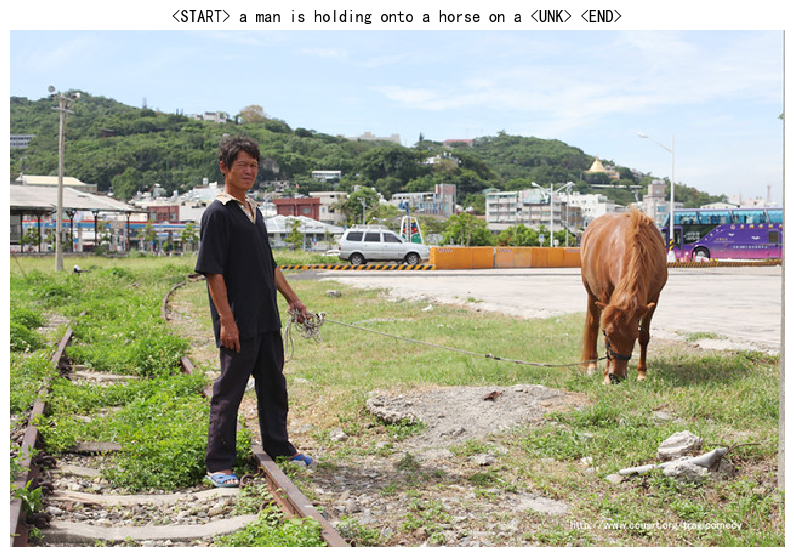

URL Error:  Not Found http://farm4.staticflickr.com/3142/3286956547_0d4b168ece_z.jpg


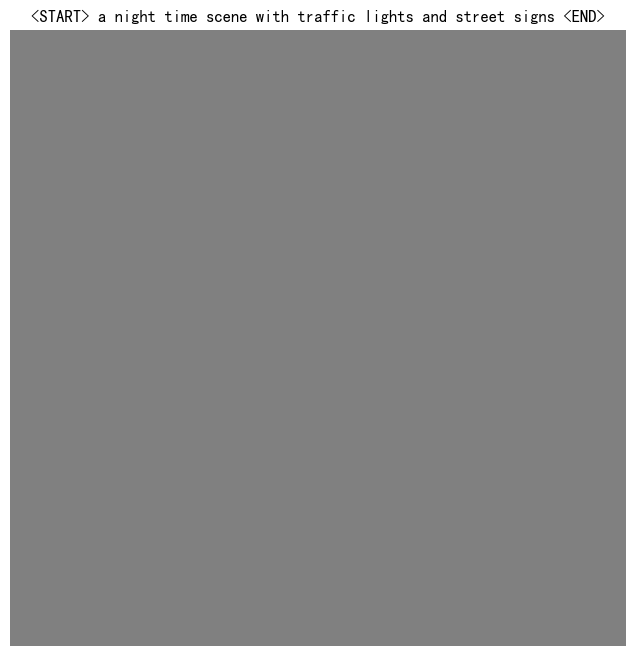

URL Error:  Not Found http://farm9.staticflickr.com/8197/8179274130_5e86a990c4_z.jpg


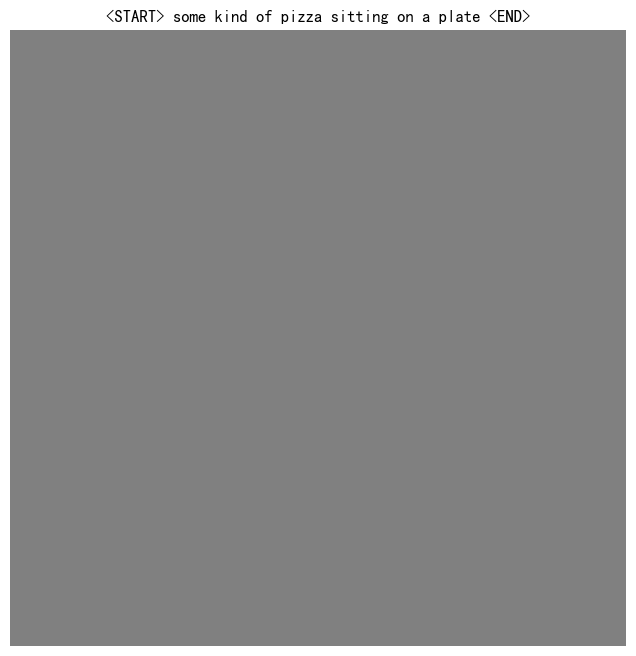

In [20]:
# 采样一个小批量数据并显示图像和字幕。
# 如果您遇到错误，那只是因为 URL 不再存在，所以不必担心！
# 您可以根据需要多次重新采样。
batch_size = 3

captions, features, urls = sample_coco_minibatch(data, batch_size=batch_size)
for i, (caption, url) in enumerate(zip(captions, urls)):
    plt.imshow(image_from_url(url))
    plt.axis('off')
    caption_str = decode_captions(caption, data['idx_to_word'])
    plt.title(caption_str)
    plt.show()

# 循环神经网络 (Recurrent Neural Network)
正如课程中所讨论的，我们将使用循环神经网络 (RNN) 语言模型来进行图像字幕生成。 `cs231n/rnn_layers_pytorch.py` 文件包含了不同类型层的实现 这是循环神经网络所需的， 而 `cs231n/classifiers/rnn_pytorch.py` 文件则使用这些层来实现了一个图像字幕模型。

我们将首先在 `cs231n/rnn_layers_pytorch.py` 中实现不同类型的 RNN 层。

_更深入理解 RNN 的可选阅读材料 : https://www.deeplearningbook.org/contents/rnn.html#pf7_

# 普通 RNN: 单步前向传播 (Step Forward)
打开文件 `cs231n/rnn_layers_pytorch.py`。 该文件实现了循环神经网络中常用不同类型层的前向传播 。 请注意，由于我们使用 PyTorch，反向传播将由 PyTorch 的 autograd 自动处理。

首先实现 `rnn_step_forward` 函数， 该函数实现了普通循环神经网络单个时间步的前向传播。 完成后运行以下代码检查您的实现。 您应该看到误差在 e-8 数量级或更小。

In [21]:
N, D, H = 3, 10, 4

x = torch.from_numpy(np.linspace(-0.4, 0.7, num=N*D).reshape(N, D))
prev_h = torch.from_numpy(np.linspace(-0.2, 0.5, num=N*H).reshape(N, H))
Wx = torch.from_numpy(np.linspace(-0.1, 0.9, num=D*H).reshape(D, H))
Wh = torch.from_numpy(np.linspace(-0.3, 0.7, num=H*H).reshape(H, H))
b = torch.from_numpy(np.linspace(-0.2, 0.4, num=H))

next_h = rnn_step_forward(x, prev_h, Wx, Wh, b).numpy()
expected_next_h = np.asarray([
  [-0.58172089, -0.50182032, -0.41232771, -0.31410098],
  [ 0.66854692,  0.79562378,  0.87755553,  0.92795967],
  [ 0.97934501,  0.99144213,  0.99646691,  0.99854353]])

print('next_h error: ', rel_error(expected_next_h, next_h))

next_h error:  6.292421426471037e-09


# 普通 RNN: 单步反向传播 (Step Backward)
由于我们使用 PyTorch 实现了 `rnn_step_forward`，我们**不必**实现 `rnn_step_backward`。 我们可以使用我们的数值梯度检查器来验证 PyTorch autograd 的反向传播。


但是，如果您有兴趣挑战一下，您可以尝试自己实现 `rnn_step_backward`。 不过，本作业并不要求这么做。

In [22]:
from cs231n.rnn_layers_pytorch import rnn_step_forward

# 创建测试输入
np.random.seed(231)
N, D, H = 4, 5, 6
x = torch.from_numpy(np.random.randn(N, D))
h = torch.from_numpy(np.random.randn(N, H))
Wx = torch.from_numpy(np.random.randn(D, H))
Wh = torch.from_numpy(np.random.randn(H, H))
b = torch.from_numpy(np.random.randn(H))

# 启用梯度追踪并进行 rnn 前向传播
for tensor in [x, h, Wx, Wh, b]:
  tensor.requires_grad_()
next_h = rnn_step_forward(x, h, Wx, Wh, b)

# 模拟随机的上游梯度并使用 PyTorch 的 autograd
# 执行反向传播。
dnext_h = torch.from_numpy(np.random.randn(*next_h.shape))
next_h.backward(dnext_h)

# 将梯度收集到独立的 numpy 数组中
dx = x.grad.detach().numpy()
dh = h.grad.detach().numpy()
dWx = Wx.grad.detach().numpy()
dWh = Wh.grad.detach().numpy()
db = b.grad.detach().numpy()
dnext_h = dnext_h.detach().numpy()

# 同样将测试输入转换为 numpy 数组
x =  x.detach().numpy()
h =  h.detach().numpy()
Wx = Wx.detach().numpy()
Wh = Wh.detach().numpy()
b =  b.detach().numpy()

# 封装我们的前向传播以支持 numpy 数组的输入和输出。我们使用
# `torch.no_grad()` 来显式地禁用梯度追踪。
def rnn_step_forward_numpy(x, h, Wx, Wh, b):
  with torch.no_grad():
    return rnn_step_forward(
        torch.from_numpy(x),
        torch.from_numpy(h),
        torch.from_numpy(Wx),
        torch.from_numpy(Wh),
        torch.from_numpy(b),
    ).numpy()

# 计算数值梯度并进行比较。
fx = lambda x: rnn_step_forward_numpy(x, h, Wx, Wh, b)
fh = lambda h: rnn_step_forward_numpy(x, h, Wx, Wh, b)
fWx = lambda Wx: rnn_step_forward_numpy(x, h, Wx, Wh, b)
fWh = lambda Wh: rnn_step_forward_numpy(x, h, Wx, Wh, b)
fb = lambda b: rnn_step_forward_numpy(x, h, Wx, Wh, b)

dx_num = eval_numerical_gradient_array(fx, x, dnext_h)
dh_num = eval_numerical_gradient_array(fh, h, dnext_h)
dWx_num = eval_numerical_gradient_array(fWx, Wx, dnext_h)
dWh_num = eval_numerical_gradient_array(fWh, Wh, dnext_h)
db_num = eval_numerical_gradient_array(fb, b, dnext_h)

# 您应该看到误差在 1e-9 数量级或更小
print('dx error: ', rel_error(dx_num, dx))
print('dh error: ', rel_error(dh_num, dh))
print('dWx error: ', rel_error(dWx_num, dWx))
print('dWh error: ', rel_error(dWh_num, dWh))
print('db error: ', rel_error(db_num, db))

dx error:  2.319932372313319e-10
dh error:  2.6828355645784327e-10
dWx error:  8.820244454238703e-10
dWh error:  4.703287554560559e-10
db error:  1.5956895526227225e-11


# 普通 RNN: 前向传播 (Forward)
现在您已经实现了普通 RNN 单个时间步的前向传播， 您将使用它来实现处理整个数据序列的 RNN。

在文件 `cs231n/rnn_layers_pytorch.py` 中，实现 `rnn_forward` 函数。 这应该使用您在上面定义的 `rnn_step_forward` 函数来实现。 完成后运行以下代码检查您的实现。 您应该看到误差在 `e-7` 数量级或更小。

In [23]:
from cs231n.rnn_layers_pytorch import rnn_forward

N, T, D, H = 2, 3, 4, 5

x = torch.from_numpy(np.linspace(-0.1, 0.3, num=N*T*D).reshape(N, T, D))
h0 = torch.from_numpy(np.linspace(-0.3, 0.1, num=N*H).reshape(N, H))
Wx = torch.from_numpy(np.linspace(-0.2, 0.4, num=D*H).reshape(D, H))
Wh = torch.from_numpy(np.linspace(-0.4, 0.1, num=H*H).reshape(H, H))
b = torch.from_numpy(np.linspace(-0.7, 0.1, num=H))

h = rnn_forward(x, h0, Wx, Wh, b).numpy()
expected_h = np.asarray([
  [
    [-0.42070749, -0.27279261, -0.11074945,  0.05740409,  0.22236251],
    [-0.39525808, -0.22554661, -0.0409454,   0.14649412,  0.32397316],
    [-0.42305111, -0.24223728, -0.04287027,  0.15997045,  0.35014525],
  ],
  [
    [-0.55857474, -0.39065825, -0.19198182,  0.02378408,  0.23735671],
    [-0.27150199, -0.07088804,  0.13562939,  0.33099728,  0.50158768],
    [-0.51014825, -0.30524429, -0.06755202,  0.17806392,  0.40333043]]])
print('h error: ', rel_error(expected_h, h))

h error:  7.728466180186066e-08


# 普通 RNN: 反向传播 (Backward)
As before, we can verify pytorch autograd backward  如果您愿意，也可以尝试自己实现 `rnn_step_backward`。 不过，本作业并不要求这么做。



In [24]:
from cs231n.rnn_layers_pytorch import rnn_forward

# 创建测试输入
np.random.seed(231)
N, D, T, H = 2, 3, 10, 5
x = torch.from_numpy(np.random.randn(N, T, D))
h0 = torch.from_numpy(np.random.randn(N, H))
Wx = torch.from_numpy(np.random.randn(D, H))
Wh = torch.from_numpy(np.random.randn(H, H))
b = torch.from_numpy(np.random.randn(H))

# 启用梯度追踪并进行前向传播
for tensor in [x, h0, Wx, Wh, b]:
  tensor.requires_grad_()
h = rnn_forward(x, h0, Wx, Wh, b)

# 模拟随机的上游梯度并使用 PyTorch 的 autograd
# 执行反向传播。
dh = torch.from_numpy(np.random.randn(*h.shape))
h.backward(dh)

# 将梯度收集到独立的 numpy 数组中
dx = x.grad.detach().numpy()
dh0 = h0.grad.detach().numpy()
dWx = Wx.grad.detach().numpy()
dWh = Wh.grad.detach().numpy()
db = b.grad.detach().numpy()
dh = dh.detach().numpy()

# 同样将测试输入转换为 numpy 数组
x =  x.detach().numpy()
h0 =  h0.detach().numpy()
Wx = Wx.detach().numpy()
Wh = Wh.detach().numpy()
b =  b.detach().numpy()

# 封装我们的前向传播以支持 numpy 数组的输入和输出。我们使用
# `torch.no_grad()` 来显式地禁用梯度追踪。
def rnn_forward_numpy(x, h0, Wx, Wh, b):
  with torch.no_grad():
    return rnn_forward(
        torch.from_numpy(x),
        torch.from_numpy(h0),
        torch.from_numpy(Wx),
        torch.from_numpy(Wh),
        torch.from_numpy(b),
    ).numpy()


fx = lambda x: rnn_forward_numpy(x, h0, Wx, Wh, b)
fh0 = lambda h0: rnn_forward_numpy(x, h0, Wx, Wh, b)
fWx = lambda Wx: rnn_forward_numpy(x, h0, Wx, Wh, b)
fWh = lambda Wh: rnn_forward_numpy(x, h0, Wx, Wh, b)
fb = lambda b: rnn_forward_numpy(x, h0, Wx, Wh, b)

dx_num = eval_numerical_gradient_array(fx, x, dh)
dh0_num = eval_numerical_gradient_array(fh0, h0, dh)
dWx_num = eval_numerical_gradient_array(fWx, Wx, dh)
dWh_num = eval_numerical_gradient_array(fWh, Wh, dh)
db_num = eval_numerical_gradient_array(fb, b, dh)

# 您应该看到误差在 1e-6 数量级或更小
print('dx error: ', rel_error(dx_num, dx))
print('dh0 error: ', rel_error(dh0_num, dh0))
print('dWx error: ', rel_error(dWx_num, dWx))
print('dWh error: ', rel_error(dWh_num, dWh))
print('db error: ', rel_error(db_num, db))

dx error:  2.4180851680932135e-09
dh0 error:  3.3811400640982614e-09
dWx error:  7.2217238007937085e-09
dWh error:  1.2821246475483426e-07
db error:  4.676348457243789e-10


# 词嵌入 (Word Embedding): 前向传播
在深度学习系统中，我们通常使用向量来表示单词。 词汇表中的每个单词都将关联一个向量， 并且这些向量将与系统的其余部分联合学习。

在文件 `cs231n/rnn_layers_pytorch.py` 中，实现 `word_embedding_forward` 函数 以将单词 (由整数表示) 转换为向量。 运行以下代码来检查您的实现。 您应该看到误差在 `e-8` 数量级或更小。

In [25]:
N, T, V, D = 2, 4, 5, 3

x = torch.from_numpy(np.asarray([[0, 3, 1, 2], [2, 1, 0, 3]]))
W = torch.from_numpy(np.linspace(0, 1, num=V*D).reshape(V, D))

out = word_embedding_forward(x, W).numpy()
expected_out = np.asarray([
 [[ 0.,          0.07142857,  0.14285714],
  [ 0.64285714,  0.71428571,  0.78571429],
  [ 0.21428571,  0.28571429,  0.35714286],
  [ 0.42857143,  0.5,         0.57142857]],
 [[ 0.42857143,  0.5,         0.57142857],
  [ 0.21428571,  0.28571429,  0.35714286],
  [ 0.,          0.07142857,  0.14285714],
  [ 0.64285714,  0.71428571,  0.78571429]]])

print('out error: ', rel_error(expected_out, out))

out error:  1.0000000094736443e-08


# 词嵌入 (Word Embedding): 反向传播
As before, we can verify pytorch autograd backward  如果您愿意，您也可以尝试自己实现 `word_embedding_backward`。 不过，本作业并不要求这么做。

In [26]:
np.random.seed(231)

N, T, V, D = 50, 3, 5, 6
x = torch.from_numpy(np.random.randint(V, size=(N, T)))
W = torch.from_numpy(np.random.randn(V, D))
W.requires_grad_()

out = word_embedding_forward(x, W)
dout = torch.from_numpy(np.random.randn(*out.shape))
out.backward(dout)

dW = W.grad.detach().numpy()
x = x.detach().numpy()
W = W.detach().numpy()
dout = dout.detach().numpy()

def word_embedding_forward_numpy(x, W):
  return word_embedding_forward(
      torch.from_numpy(x),
      torch.from_numpy(W),
  ).numpy()

f = lambda W: word_embedding_forward_numpy(x, W)
dW_num = eval_numerical_gradient_array(f, W, dout)

# 您应该看到误差在 1e-11 数量级或更小
print('dW error: ', rel_error(dW, dW_num))

dW error:  3.2774595693100364e-12


# 时间序列仿射层 (Temporal Affine Layer)
在每个时间步，我们使用仿射函数 (affine function) 将该时间步的 RNN 隐藏向量转换为词汇表中每个单词的得分。 因为这与您在作业 1 中实现的仿射层非常相似， 我们在 `temporal_affine_forward` 中为您提供了此函数。 运行以下代码对该实现进行数值梯度检查。 您应该看到误差在 `e-9` 数量级或更小。

In [29]:
np.random.seed(231)

# 时间序列仿射层的梯度检查
N, T, D, M = 2, 3, 4, 5
x = torch.from_numpy(np.random.randn(N, T, D))
w = torch.from_numpy(np.random.randn(D, M))
b = torch.from_numpy(np.random.randn(M))

for tensor in [x, w, b]:
  tensor.requires_grad_()
out = temporal_affine_forward(x, w, b)
dout = torch.from_numpy(np.random.randn(*out.shape))
out.backward(dout)

dx = x.grad.detach().numpy()
dw = w.grad.detach().numpy()
db = b.grad.detach().numpy()

x = x.detach().numpy()
w = w.detach().numpy()
b = b.detach().numpy()
dout = dout.detach().numpy()

def temporal_affine_forward_numpy(x, w, b):
  return temporal_affine_forward(
      torch.from_numpy(x),
      torch.from_numpy(w),
      torch.from_numpy(b),
  ).numpy()

fx = lambda x: temporal_affine_forward_numpy(x, w, b)
fw = lambda w: temporal_affine_forward_numpy(x, w, b)
fb = lambda b: temporal_affine_forward_numpy(x, w, b)

dx_num = eval_numerical_gradient_array(fx, x, dout)
dw_num = eval_numerical_gradient_array(fw, w, dout)
db_num = eval_numerical_gradient_array(fb, b, dout)

print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

dx error:  2.9215854231394017e-10
dw error:  1.5772088618663602e-10
db error:  3.252209560097257e-11


# 时间序列 Softmax 损失 (Temporal Softmax Loss)
在 RNN 语言模型中，在每个时间步我们都会产生词汇表中每个单词的得分。 我们知道每个时间步的真实标记 (ground-truth word)， 因此我们使用 softmax 损失函数来计算每个时间步的损失和梯度。 我们对时间维度上的损失进行求和，并在小批量 (minibatch) 内取平均。

然而这里有一个小问题：由于我们在小批量上操作，且不同的字幕可能有不同的长度， 我们在每个字幕的末尾追加了 `<NULL>` 标记以使它们具有相同的长度。 我们不希望这些 `<NULL>` 标记计入损失或梯度， 因此除了得分和真实标签外，我们的损失函数还接收一个 `mask` 数组， 用于告诉它得分的哪些元素应该被计入损失。

由于这与您在作业 1 中实现的 softmax 损失函数非常相似， 我们已经为您实现了这个损失函数； 请查看文件 `cs231n/rnn_layers_pytorch.py` 中的 `temporal_softmax_loss` 函数。

运行以下单元格以对损失进行健全性检查 (sanity check) 并对该函数执行数值梯度检查。 您应该看到 dx 的误差在 `e-7` 数量级或更小。

In [31]:
# 时间序列 softmax 损失的健全性检查
from cs231n.rnn_layers_pytorch import temporal_softmax_loss

N, T, V = 100, 1, 10

def check_loss(N, T, V, p):
    x = 0.001 * torch.from_numpy(np.random.randn(N, T, V))
    y = torch.from_numpy(np.random.randint(V, size=(N, T)))
    mask = torch.from_numpy(np.random.rand(N, T)) <= p
    print(temporal_softmax_loss(x, y, mask).item())

check_loss(100, 1, 10, 1.0)   # Should be about 2.3
check_loss(100, 10, 10, 1.0)  # Should be about 23
check_loss(5000, 10, 10, 0.1) # Should be within 2.2-2.4

# 时间序列 softmax 损失的梯度检查
np.random.seed(231231)
N, T, V = 7, 8, 9

x = torch.from_numpy(np.random.randn(N, T, V))
y = torch.from_numpy(np.random.randint(V, size=(N, T)))
mask = torch.from_numpy(np.random.rand(N, T) > 0.5)

x.requires_grad_()
loss = temporal_softmax_loss(x, y, mask, verbose=False)
loss.backward()
dx = x.grad.detach().numpy()
x = x.detach().numpy()
dx_num = eval_numerical_gradient(
    lambda x: temporal_softmax_loss(torch.from_numpy(x), y, mask), x, verbose=False)

print('dx error: ', rel_error(dx, dx_num))

2.3026293153565907
23.025737660721724
2.26343490470548
dx error:  5.5228696963589426e-08


# 用于图像字幕生成的 RNN
现在您已经实现了必要的层，您可以将它们组合起来构建一个图像字幕模型。 打开文件 `cs231n/classifiers/rnn_pytorch.py` 并查看 `CaptioningRNN` 类。

在 `loss` 函数中实现模型的前向传播。 现在您只需要实现普通 RNN 的情况 (`cell_type='rnn'`)； 您将在后面实现 LSTM 的情况。 完成后，运行以下代码使用一个小测试用例检查您的前向传播； 您应该看到误差在 `e-10` 数量级或更小。

In [33]:
N, D, W, H = 10, 20, 30, 40
word_to_idx = {'<NULL>': 0, 'cat': 2, 'dog': 3}
V = len(word_to_idx)
T = 13

model = CaptioningRNN(
    word_to_idx,
    input_dim=D,
    wordvec_dim=W,
    hidden_dim=H,
    cell_type='rnn',
    dtype=torch.float64
)

# 将所有模型参数设置为固定值
for k, v in model.params.items():
    model.params[k] = torch.from_numpy(
        np.linspace(-1.4, 1.3, num=v.numel()).reshape(*v.shape))

features = torch.from_numpy(np.linspace(-1.5, 0.3, num=(N * D)).reshape(N, D))
captions = torch.from_numpy((np.arange(N * T) % V).reshape(N, T))

loss = model.loss(features, captions).item()
expected_loss = 9.83235591003

print('loss: ', loss)
print('expected loss: ', expected_loss)
print('difference: ', abs(loss - expected_loss))

loss:  9.83235591002739
expected loss:  9.83235591003
difference:  2.609468197078968e-12


运行以下单元格以对 `CaptioningRNN` 类执行数值梯度检查； 您应该看到误差在 `e-6` 数量级或更小左右。

In [34]:
np.random.seed(231)
torch.manual_seed(231)

batch_size = 2
timesteps = 3
input_dim = 4
wordvec_dim = 5
hidden_dim = 6
word_to_idx = {'<NULL>': 0, 'cat': 2, 'dog': 3}
vocab_size = len(word_to_idx)

captions = torch.from_numpy(np.random.randint(vocab_size, size=(batch_size, timesteps)))
features = torch.from_numpy(np.random.randn(batch_size, input_dim))

model = CaptioningRNN(
    word_to_idx,
    input_dim=input_dim,
    wordvec_dim=wordvec_dim,
    hidden_dim=hidden_dim,
    cell_type='rnn',
    dtype=torch.float64,
)

for k, v in model.params.items():
  v.requires_grad_()
loss = model.loss(features, captions)
loss.backward()
grads = {k: v.grad.detach().numpy() for k, v in model.params.items()}
for k, v in model.params.items():
  v.requires_grad_(False)

for param_name in sorted(grads.keys()):
    def fn(val):
      model.params[param_name] = torch.from_numpy(val)
      ret = model.loss(features, captions).numpy()
      return ret

    param_grad_num = eval_numerical_gradient(
        fn, model.params[param_name].numpy(), verbose=False, h=1e-6)

    e = rel_error(param_grad_num, grads[param_name])
    print('%s relative error: %e' % (param_name, e))

W_embed relative error: 7.405825e-09
W_proj relative error: 1.627846e-08
W_vocab relative error: 5.813051e-09
Wh relative error: 3.722645e-09
Wx relative error: 3.272434e-06
b relative error: 2.259961e-10
b_proj relative error: 7.720396e-10
b_vocab relative error: 4.089136e-09


# 在小数据上过拟合 RNN 字幕模型
与我们上个作业中用来训练图像分类模型的 `Solver` 类相似， 在此作业中，我们使用 `CaptioningSolverPytorch` 类来训练图像字幕模型。 打开 `cs231n/captioning_solver_pytorch.py` 文件并阅读 `CaptioningSolverPytorch` 类； 它应该看起来非常熟悉。

在您熟悉了 API 之后，运行以下代码以确保您的模型能够在 100 个训练样本的小样本上过拟合。 您应该会看到最终的损失小于 0.1。

base dir  D:\Python\west2AI\LYFshota.me\cs231n-Assignment 2-25\cs231n\datasets/coco_captioning
(Iteration 1 / 100) loss: 80.027161
(Iteration 11 / 100) loss: 25.581413
(Iteration 21 / 100) loss: 3.890581
(Iteration 31 / 100) loss: 0.641152
(Iteration 41 / 100) loss: 0.133206
(Iteration 51 / 100) loss: 0.057617
(Iteration 61 / 100) loss: 0.028610
(Iteration 71 / 100) loss: 0.022360
(Iteration 81 / 100) loss: 0.018525
(Iteration 91 / 100) loss: 0.016730


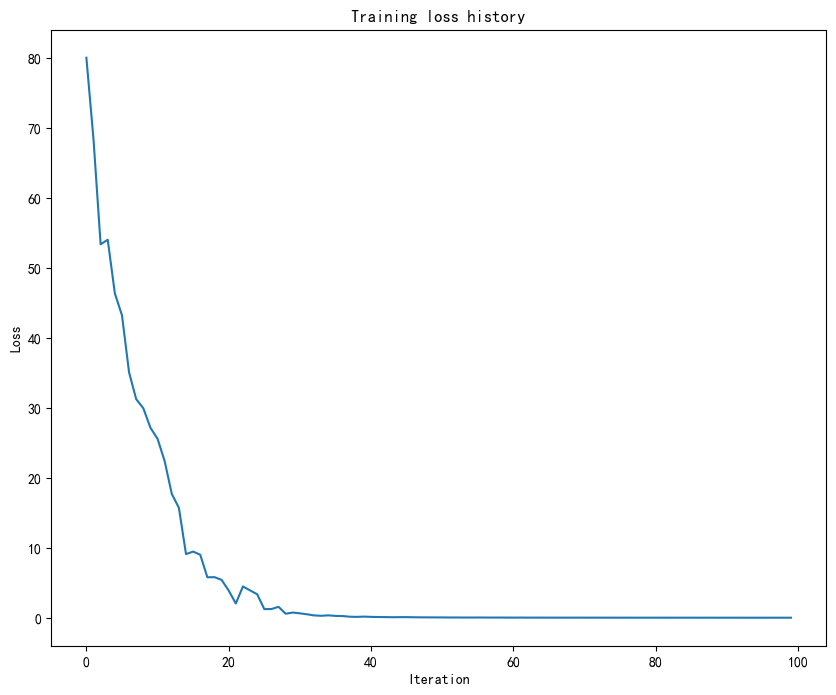

In [35]:
np.random.seed(231)
torch.manual_seed(231)

small_data = load_coco_data(max_train=50)

small_rnn_model = CaptioningRNN(
    cell_type='rnn',
    word_to_idx=data['word_to_idx'],
    input_dim=data['train_features'].shape[1],
    hidden_dim=512,
    wordvec_dim=256,
)

small_rnn_solver = CaptioningSolverPytorch(
    small_rnn_model, small_data,
    num_epochs=50,
    batch_size=25,
    learning_rate=5e-3,
    verbose=True, print_every=10,
)

small_rnn_solver.train()

# 绘制训练损失。
plt.plot(small_rnn_solver.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training loss history')
plt.show()

Print final training loss. 您应该会看到最终的损失小于 0.1。

In [ ]:
print('Final loss: ', small_rnn_solver.loss_history[-1])

# 测试时的 RNN 采样 (Sampling at Test Time)
与分类模型不同，图像字幕模型在训练时与测试时的行为有很大差异。 在训练时，我们可以获取真实的字幕， 因此在每个时间步我们将真实的单词作为输入馈送给 RNN。 而在测试时，我们在每个时间步从词汇表的分布中进行采样， 并将该采样结果作为输入馈送给 RNN 的下一个时间步。

在文件 `cs231n/classifiers/rnn_pytorch.py` 中，实现用于测试时采样的 `sample` 方法。 完成后，运行以下代码以从您在训练数据和验证数据上的过拟合模型中进行采样。 在训练数据上的采样结果应该非常好。 然而，在验证数据上的采样结果可能没什么意义。

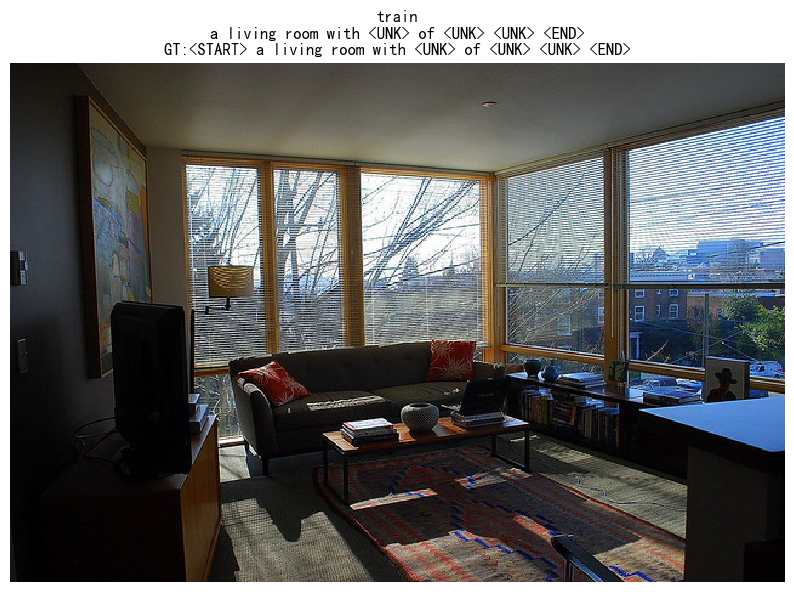

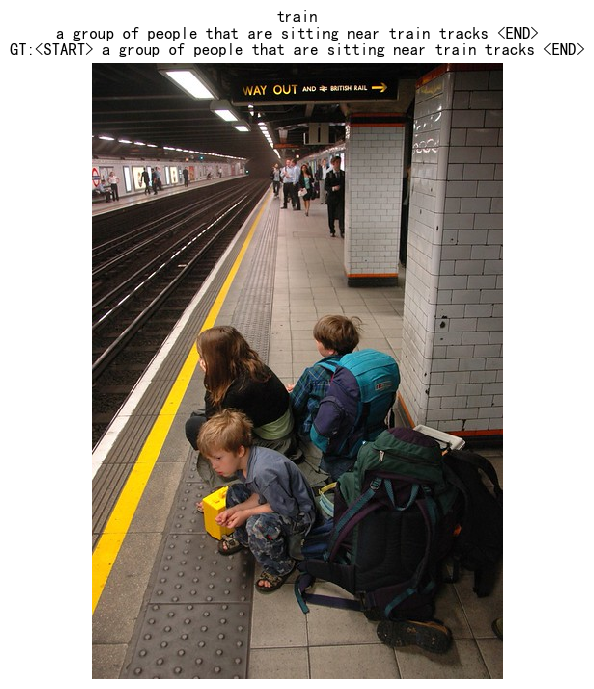

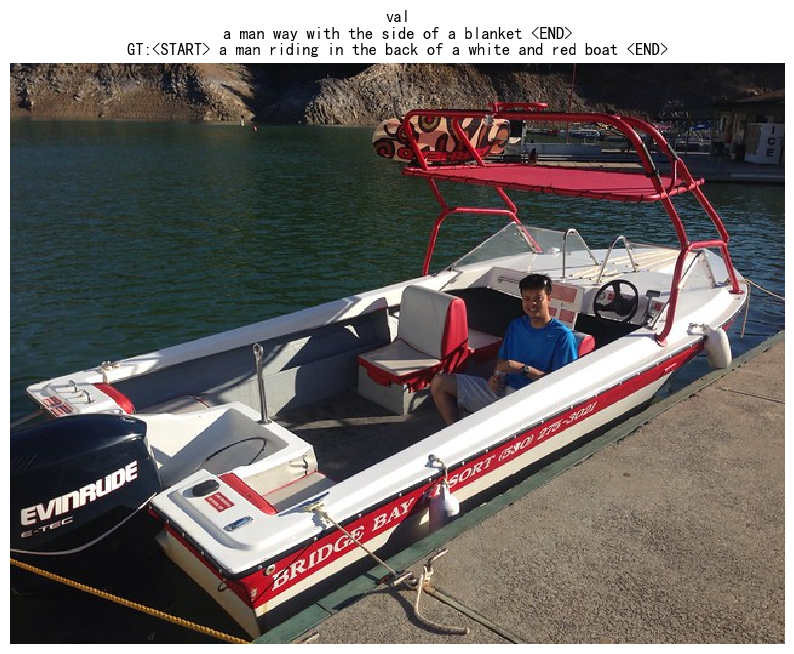

URL Error:  Gone http://farm8.staticflickr.com/7185/6958105247_8e397d24c0_z.jpg


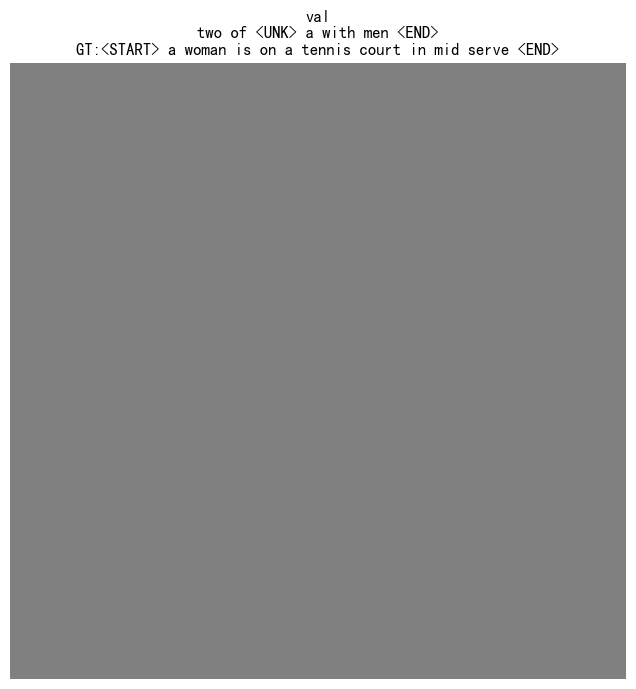

In [36]:
# 如果您遇到错误，那只是因为 URL 不再存在，所以不必担心！
# 您可以根据需要多次重新采样。
for split in ['train', 'val']:
    minibatch = sample_coco_minibatch(small_data, split=split, batch_size=2)
    gt_captions, features, urls = minibatch
    gt_captions = decode_captions(gt_captions, data['idx_to_word'])

    sample_captions = small_rnn_model.sample(torch.from_numpy(features)).numpy()
    sample_captions = decode_captions(sample_captions, data['idx_to_word'])

    for gt_caption, sample_caption, url in zip(gt_captions, sample_captions, urls):
        img = image_from_url(url)
        # 跳过丢失的 URL。
        if img is None: continue
        plt.imshow(img)
        plt.title('%s\n%s\nGT:%s' % (split, sample_caption, gt_caption))
        plt.axis('off')
        plt.show()

# 内联问题 1 (Inline Question 1)

在我们当前的图像字幕设置中，我们的 RNN 语言模型在每个时间步输出一个单词。 然而，另一种提出问题的方式是训练网络以操作_字符_ (例如 'a'、'b' 等) 而不是单词， 以便在每个时间步，它接收前一个字符作为输入并尝试预测序列中的下一个字符。 例如，网络可能会生成像这样的字幕：

'A', ' ', 'c', 'a', 't', ' ', 'o', 'n', ' ', 'a', ' ', 'b', 'e', 'd'

您能描述一个使用字符级 RNN 的图像字幕模型的优势吗？ 您能再描述一个缺点吗？ 提示：有几个有效的答案，但比较词级和字符级模型的参数空间可能会有所帮助。

**您的答案：**
优势是词汇表会变的很小，大幅缩小了参数，避免了未知词的问题；缺点是序列长度会变长，导致训练和推理变慢，并且RNN更难学习长距离的语法还有语义之间的关系。
